---
exports:
- format: pdf
  template: arxiv_two_column
  output: bayesian-machine-learning.pdf
  id: bayesian-machine-learning-pdf
downloads:
  - id: bayesian-machine-learning-pdf
---

# Bayesian Machine Learning

# Philosophical Foundations and Bayes’ Theorem

## Interpretations of probability

**Frequentist definition**: Probability of event $E$ is the *long-run relative frequency* of $E$ in infinitely many repetitions of the same experiment. Statements are about data, not parameters ($P(E)$ is defined via an idealized limit of repetitions).

**Bayesian definition**: Probability is a *subjective degree of belief* about events or parameters, given current knowledge ($P(E)$ quantifies how plausible you think $E$ is).

### Key philosophical contrast

**Frequentist:** uncertainty is in the *world* (randomness of experiments).

**Bayesian:** uncertainty is in the *head* of the observer (state of information; different observers with different prior knowledge can have different probabilities).

## Sampling vs. inference

**Sampling (forward problem)**: Assume parameter is known, ask: "If $p$ is the probability of success, what is $P(Y = k \mid p)$?". For example: Number of heads in 10 tosses with known $p$ ~ Binomial($n=10, p$).

**Inference (inverse problem)**: Assume data is observed, but the parameters are unknown, ask: "Given I observed $k$ heads in 10 tosses, what do I believe about $p$?"

_Frequentist:_ Estimate single “best” value (e.g. MLE $\hat p = k/n$)

_Bayesian:_ derive a *posterior distribution* over $p$: $p(p \mid \text{data})$

## Bayes’ theorem and roles of likelihood

**Bayes’ theorem (discrete)**: $P(A \mid B) = \frac{P(B\mid A)P(A)}{P(B)}$

**Belief-updater view**: $\underbrace{P(A\mid d)}_{\text{posterior}}\propto\underbrace{P(d\mid A)}_{\text{likelihood}}\times\underbrace{P(A)}_{\text{prior}}$

**Prior**: beliefs before data.

**Likelihood**: how plausible data are under different parameter values.

**Posterior**: updated beliefs after data.

**Likelihood in both schools**:

In **frequentist statistics**, the likelihood function is used to perform **Maximum Likelihood Estimation (MLE)**. This identifies the single parameter value that maximizes the probability of having produced the observed data.

In **Bayesian statistics**, the likelihood function serves as a **belief updater**. It is multiplied by the prior distribution to calculate the posterior, allowing you to estimate a full distribution of all plausible values rather than just one "best" number.

## When Bayesian methods are preferable

**Small sample sizes / rare events**: frequentist asymptotics unreliable.

**Strong prior information** available (expert opinion, previous studies) and should be integrated.

**Need full uncertainty quantification** (posterior distributions, credible intervals) rather than point estimates or p-values.

**Complex hierarchical or graphical models**, where likelihood-based methods get complicated but Bayesian methods remain conceptually coherent.


## The computational curse of Bayesian statistics

Core difficulty: the **evidence** (marginal likelihood) is an often intractable integral: $p(d) = \int p(d\mid \theta)p(\theta)\,d\theta$

In simple conjugate families this integral is analytic.

In realistic models (many parameters, non-Gaussian likelihoods), high‑dimensional integrals are impossible to compute in closed form.

This computational curse motivates **Markov Chain Monte Carlo (MCMC)** and **Variational Inference**.

# Conjugate Families and Continuous Inference

Conjugate families are pedagogically useful to understand **how priors and data trade off**.


## Beta-Binomial

**Likelihood:** $P(Y \mid \pi) \sim \text{Binomial}(n, \pi) \sim P(Y=k \mid \pi) = \binom{n}{k}\pi^k(1-\pi)^{n-k}$

$\mathbb{E}[Y] = n\pi \quad \operatorname{Var}[Y] = n\pi(1-\pi)$

$\operatorname{Mode}[Y] = \begin{cases}
\lfloor (n+1)\pi \rfloor & \text{if } (n+1)\pi \notin \mathbb{Z} \\
(n+1)\pi, (n+1)\pi - 1 & \text{if } (n+1)\pi \in \mathbb{Z}
\end{cases}
$

$\binom{n}{k}$ is the **binomial coefficient**, representing the number of ways to choose $k$ successes from $n$ trials: $\binom{n}{k} = \frac{n!}{k!(n-k)!}$

$\pi^k$ is the probability of getting exactly $k$ successes

$(1-\pi)^{n-k}$ is the probability of getting exactly $n-k$ failures

**Prior:** $P(\pi) \sim \text{Beta}(\pi \mid \alpha,\beta) = \frac{\Gamma(\alpha + \beta)}{\Gamma(\alpha)\Gamma(\beta)} \pi^{\alpha-1}(1-\pi)^{\beta-1}$

with: $\Gamma(n) = (n - 1)! \quad \forall n \in \mathbb{N}$

$\mathbb{E}[\pi] = \frac{\alpha}{\alpha + \beta} \quad \operatorname{Var}[\pi] = \frac{\alpha\beta}{(\alpha+\beta)^2(\alpha+\beta+1)}$

$\operatorname{Mode}[\pi] = \dfrac{\alpha - 1}{\alpha + \beta - 2} \quad \text{if } \alpha, \beta > 1$

**Posterior:** $P(\pi \mid Y=k) = \text{Beta}(\alpha + k, \beta + n - k)$

**Key properties**:
Prior “pseudo-counts”: $\alpha-1$ successes, $\beta-1$ failures

With more data, likelihood dominates; with little data, prior dominates

Order of data does not matter; only sufficient statistics $(n,k)$

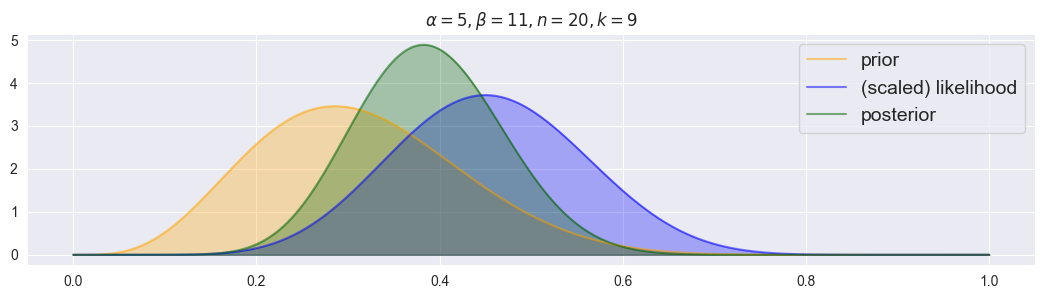

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def plot_beta_binomial( alpha, beta, n, k, figsize=(13,3) ):
    # create figure
    plt.figure( figsize=figsize )

    # numeric evaluation range for pi
    pi_range = np.linspace(0, 1, 1000)

    # prior
    prior = [stats.beta.pdf(pi, a=alpha, b=beta) for pi in pi_range]
    plt.plot( pi_range, prior, alpha=0.5, label="prior", c="orange" )
    plt.fill_between( pi_range, prior, alpha=0.3, color="orange" )

    # scaled likelihood
    likelihood = [stats.binom.pmf(n=n, k=k, p=pi) for pi in pi_range]
    likelihood /= np.sum( likelihood ) * (pi_range[1]-pi_range[0])
    plt.plot( pi_range, likelihood, alpha=0.5, label="(scaled) likelihood", c="blue" )
    plt.fill_between( pi_range, likelihood, alpha=0.3, color="blue" )

    # posterior
    posterior = [stats.beta.pdf(pi, a=alpha+k, b=beta+n-k) for pi in pi_range]
    plt.plot( pi_range, posterior, alpha=0.5, label="posterior", color="darkgreen" )
    plt.fill_between( pi_range, posterior, alpha=0.3, color="darkgreen" )

    # enable legend and set descriptive title
    plt.legend( fontsize=14 )
    plt.title( "$\\alpha = {}, \\beta={}, n={}, k={}$".format(alpha, beta, n, k) )

plot_beta_binomial(alpha=5, beta=11, n=20, k=9)

<Axes: >

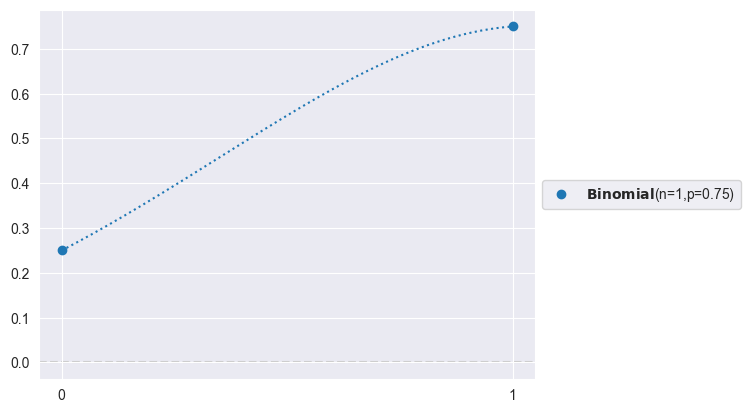

In [6]:
# Likelihood (Binomial counts):
import preliz as pz
pz.Binomial(n=1, p=0.75).plot_pdf()

<Axes: >

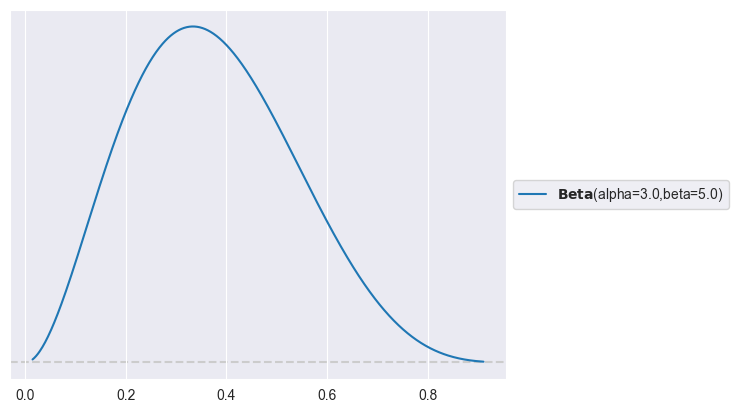

In [7]:
# Prior:
import preliz as pz
pz.Beta(alpha=3, beta=5).plot_pdf()

## Poisson–Gamma: For Counts

**Likelihood:** $P(Y \mid \lambda) \sim \text{Poisson}(\lambda) \sim P(Y = y \mid \lambda) = \frac{e^{-\lambda}\lambda^y}{y!}$

$\mathbb{E}[Y] = \lambda \quad \text{Var}[Y] = \lambda$

$\operatorname{Mode}[\lambda] = \begin{cases}
\lfloor \lambda \rfloor & \text{if } \lambda \text{ is not an integer} \\
\lambda, \lambda - 1 & \text{if } \lambda \text{ is an integer}
\end{cases}$

-  $\lambda^y$ is the contribution from $y$ events occurring
-  $e^{-\lambda}$ is the probability of no other events occurring
-  $\frac{1}{y!}$ normalizes for the ordering of events

**Prior:** $P(\lambda) \sim \text{Gamma}(s, r) \sim \frac{r^s}{\Gamma(s)}\lambda^{s-1}e^{-r\lambda}$

with $\Gamma(s) = (s-1)! \quad \forall n \in \mathbb{N}$

$\mathbb{E}[\lambda] = \frac{s}{r} \quad \text{Var}[\lambda] = \frac{s}{r^2} \quad \operatorname{Mode}[\lambda] = \frac{s - 1}{r} \quad \text{for } s \geq 1$

**Posterior:** $P(\lambda \mid Y = y) \sim \text{Gamma}\left(s + \sum_i y_i, r + n\right)$

**Key properties:**
Prior "pseudo-counts": $s$ represents prior event count, $r$ represents prior observation periods.

With more data, likelihood dominates; with little data, prior dominates.

Order of data does not matter; only sufficient statistic $\sum y_i$.


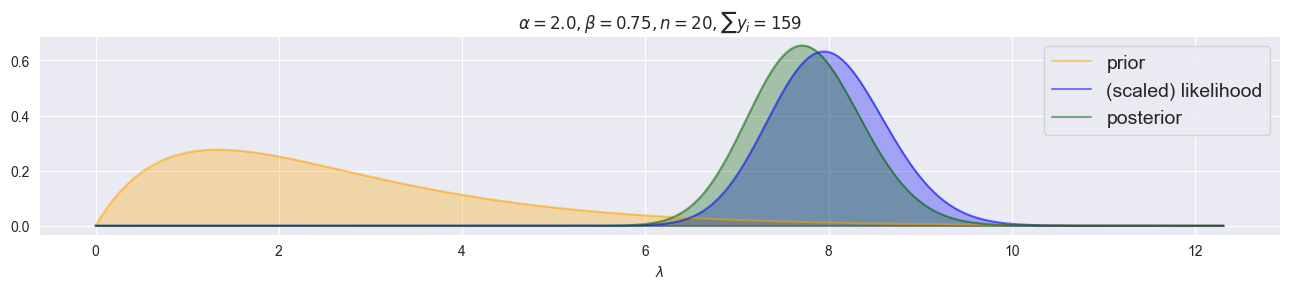

In [8]:
def plot_gamma_poisson(alpha, beta, y, figsize=(13, 3)):
    y = np.asarray(y)
    n = len(y)
    sum_y = y.sum()

    # Posterior hyperparameters
    alpha_post = alpha + sum_y
    beta_post  = beta + n

    # Choose a range for lambda using high quantiles of prior and posterior
    # (robust and adaptive to parameter scale)
    # scipy.stats.gamma uses shape 'a' and scale = 1/rate
    scale_prior = 1.0 / beta
    scale_post  = 1.0 / beta_post

    lam_max = max(
        stats.gamma.ppf(0.999, a=alpha,      scale=scale_prior),
        stats.gamma.ppf(0.999, a=alpha_post, scale=scale_post)
    )
    lam_range = np.linspace(0, lam_max, 1000)

    plt.figure(figsize=figsize)

    # Prior
    prior = stats.gamma.pdf(lam_range, a=alpha, scale=scale_prior)
    plt.plot(lam_range, prior, alpha=0.5, label="prior", c="orange")
    plt.fill_between(lam_range, prior, alpha=0.3, color="orange")

    # Likelihood as function of lambda: L(λ) = ∏_i Pois(y_i | λ)
    # Use log-likelihood for numerical stability
    log_like = np.zeros_like(lam_range)
    for yi in y:
        log_like += stats.poisson.logpmf(yi, mu=lam_range)
    likelihood = np.exp(log_like)

    # Numerically normalize likelihood over lam_range so it behaves like a pdf on this grid
    norm_const = np.trapz(likelihood, lam_range)
    if norm_const > 0:
        likelihood /= norm_const
    plt.plot(lam_range, likelihood, alpha=0.5, label="(scaled) likelihood", c="blue")
    plt.fill_between(lam_range, likelihood, alpha=0.3, color="blue")

    # Posterior
    posterior = stats.gamma.pdf(lam_range, a=alpha_post, scale=scale_post)
    plt.plot(lam_range, posterior, alpha=0.5, label="posterior", color="darkgreen")
    plt.fill_between(lam_range, posterior, alpha=0.3, color="darkgreen")

    # Legend and title
    plt.legend(fontsize=14)
    plt.xlabel(r"$\lambda$")
    plt.title(r"$\alpha = {}, \beta = {}, n = {}, \sum y_i = {}$"
              .format(alpha, beta, n, int(sum_y)))
    plt.tight_layout()
    plt.show()

plot_gamma_poisson(alpha=2.0, beta=0.75, y=[7, 8, 3, 7, 11, 7, 9, 19, 7, 15, 9, 5, 12, 3, 7, 6, 5, 3, 11, 5])

## Negative Binomial For Overdispersed Counts

Unlike the Poisson distribution, the variance is **not** equal to the mean; it is larger **(overdispersion)**. As the dispersion parameter $\alpha \to \infty$, the Negative Binomial distribution converges to the Poisson distribution. The Negative Binomial likelihood **does not have a simple closed-form conjugate posterior** - posterior inference must be done via MCMC simulation.

**Likelihood:** $P(Y \mid r, p) \sim \text{NegBin}(r, p)$

$$
\begin{aligned}
P(K = k \mid r, p) &= \binom{k+r-1}{k} (1-p)^kp^r\\
&\text{and}\\
P(K = k \mid r, \lambda) &= \frac{(r + k - 1)!}{(r - 1)! (r + \lambda)^k} \cdot \frac{\lambda^k}{k!} \cdot \frac{1}{\left(1 + \frac{\lambda}{r}\right)^r}
\end{aligned}
$$

$\mathbb{E}[k \mid r,p] = \frac{r(1-p)}{p} \quad \text{and} \quad \mathbb{E}[k \mid r, \lambda] = \lambda$

$\text{Var}[k \mid r,p] = \frac{r(1-p)}{p^2} \quad \text{and} \quad \text{Var}[k \mid r, \lambda] = \lambda\left(1 + \frac{\lambda}{r}\right)$

- $p$ probability of success
- $r$ is the number of successes (-1 because last success is fixed as its the stopping criterion)
- $k$ is the number of failures

**Prior:**
Negative Binomial is typically used in models where conjugacy does not hold. Therefore, we often use:

- in simple models $\lambda \sim \text{Gamma}(s, r)$ or in regression $\log(\lambda) = \beta_0 + \beta_1 X$ with $\beta \sim \text{Normal}$
- $r \sim \text{Gamma}$ or $r \sim \text{Exponential}$ (must be positive)

## Normal–Normal (variance needs to be known!)

**Likelihood:** $P(Y \mid \mu, \sigma) \sim \text{Normal}(\mu, \sigma^2) \sim \frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(-\frac{(y-\mu)^2}{2\sigma^2}\right)$

$\mathbb{E}[Y] = \mu \quad \text{Var}[Y] = \sigma^2 \quad \operatorname{Mode}[Y] = \mu$

-  $\mu$ is the mean (location parameter)
-  $\sigma^2$ is the variance (assumed known)
-  $(y-\mu)^2$ measures squared deviation from the mean

**Prior:** $P(\mu) \sim \text{Normal}(\mu_0, \tau_0^2)$

$\mathbb{E}[\mu] = \mu_0 \quad \text{Var}[\mu] = \tau_0^2$

-  $\mu_0$ is the prior mean
-  $\tau_0^2$ is the prior variance (reflects uncertainty about $\mu$)

**Posterior:** $P(\mu \mid Y = y) \sim \text{Normal}(\mu_n, \tau_n^2)$

$$
\mu_n = \frac{\frac{\mu_0}{\tau_0^2} + \frac{y}{\sigma^2}}{\frac{1}{\tau_0^2} + \frac{1}{\sigma^2}} = \frac{\sigma^2\mu_0 + \tau_0^2 y}{\sigma^2 + \tau_0^2},
\quad
\tau_n^2 = \frac{1}{\frac{1}{\tau_0^2} + \frac{1}{\sigma^2}} = \frac{\tau_0^2\sigma^2}{\tau_0^2 + \sigma^2}
$$

**Key properties:**
Posterior mean is a **precision-weighted average** of prior mean $\mu_0$ and data $y$.

Precision = $\frac{1}{\text{variance}}$: higher precision = more influence.

Posterior variance is always smaller than both prior and data variance (information accumulation).

With more data ($n$ observations), data precision $\frac{n}{\sigma^2}$ dominates.

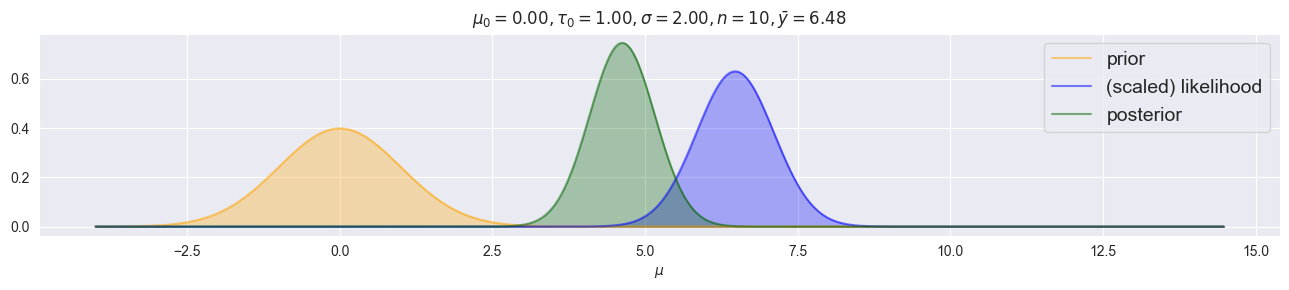

In [9]:
def plot_normal_normal(mu0, tau0, sigma, y, figsize=(13, 3)):
    y = np.asarray(y)
    n = len(y)
    ybar = y.mean()

    # Posterior variance and mean
    tau_n2 = 1.0 / (n / sigma**2 + 1.0 / tau0**2)
    mu_n = tau_n2 * (n * ybar / sigma**2 + mu0 / tau0**2)
    tau_n = np.sqrt(tau_n2)

    # Choose a plotting range for mu around data and prior
    mu_min = min(ybar - 4 * sigma, mu0 - 4 * tau0, mu_n - 4 * tau_n)
    mu_max = max(ybar + 4 * sigma, mu0 + 4 * tau0, mu_n + 4 * tau_n)
    mu_range = np.linspace(mu_min, mu_max, 1000)

    plt.figure(figsize=figsize)

    # Prior over mu
    prior = stats.norm.pdf(mu_range, loc=mu0, scale=tau0)
    plt.plot(mu_range, prior, alpha=0.5, label="prior", c="orange")
    plt.fill_between(mu_range, prior, alpha=0.3, color="orange")

    # Likelihood as function of mu (up to constant)
    # Equivalent to N(mu | ybar, sigma^2/n)
    like_unnorm = stats.norm.pdf(mu_range, loc=ybar, scale=sigma / np.sqrt(n))
    # Numerically normalize to integrate ~1 on this grid
    norm_const = np.trapz(like_unnorm, mu_range)
    likelihood = like_unnorm / norm_const if norm_const > 0 else like_unnorm

    plt.plot(mu_range, likelihood, alpha=0.5, label="(scaled) likelihood", c="blue")
    plt.fill_between(mu_range, likelihood, alpha=0.3, color="blue")

    # Posterior over mu
    posterior = stats.norm.pdf(mu_range, loc=mu_n, scale=tau_n)
    plt.plot(mu_range, posterior, alpha=0.5, label="posterior", color="darkgreen")
    plt.fill_between(mu_range, posterior, alpha=0.3, color="darkgreen")

    # Legend and title
    plt.legend(fontsize=14)
    plt.xlabel(r"$\mu$")
    plt.title(
        r"$\mu_0 = {:.2f}, \tau_0 = {:.2f}, \sigma = {:.2f}, n = {}, \bar y = {:.2f}$"
        .format(mu0, tau0, sigma, n, ybar)
    )
    plt.tight_layout()
    plt.show()

np.random.seed(0)
plot_normal_normal(mu0=0.0, tau0=1.0, sigma=2.0, y=np.random.normal(loc=5.0, scale=2.0, size=10))

## Multivariate Problems

## Covariance: Quantifying Relationship Between Variables

$$\text{Cov}(X, Y) = E[(X - \mu_X)(Y - \mu_Y)]$$

- $\text{Cov}(X, X) = \text{Var}[X] \geq 0$: A variable's covariance with itself is its variance
- $\text{Cov}(X, Y) \approx 0$: $X$ and $Y$ are unrelated; on average there is no "co-variance"

For observed data (empirical), the sample covariance is:

$$\text{cov}(x, y) = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})$$

- $\bar{x}$ and $\bar{y}$: the sample means
- $n$ is the number of observations (the denominator is $n-1$ to account for the loss of one degree of freedom when estimating the means)

## Pearson Correlation = Standardized Covariance

**Pearson correlation** normalizes covariance by the standard deviations of both variables, producing a unitless measure bounded between 0 and 1. By standardizing covariance, correlation becomes interpretable on a common scale where $r = 1$ indicates perfect positive correlation, $r = 0$ indicates no correlation, and $r = -1$ indicates perfect negative correlation.

$$\rho_{XY} = \frac{\text{Cov}(X, Y)}{\sigma_X \sigma_Y} \in [0, 1]$$

- $\sigma_X$ and $\sigma_Y$ are the standard deviations of $X$ and $Y$ respectively

For observed data (empirical), the Pearson Correlation is:

$$r(\mathbf{x}, \mathbf{y}) = \frac{\text{cov}(\mathbf{x}, \mathbf{y})}{\hat{\sigma}_x \hat{\sigma}_y}$$

- $\hat{\sigma}_x$ and $\hat{\sigma}_y$ are the sample standard deviations

## Multinomial–Dirichlet: For Categorical Counts (Generalized Beta-Binomial)

Use whenever we want to model experiments with > 2 mutually exclusive outcomes!

**Likelihood:** $P(\mathbf{K} \mid \boldsymbol{\pi}) \sim \text{Multinomial}(n, \boldsymbol{\pi})$

$$P(K_i = k_i \mid \boldsymbol{\pi}) = \frac{n!}{\prod_{i=1}^{r} k_i!} \prod_{i=1}^{r} \pi_i^{k_i}$$

$$\mathbb{E}[K_i] = n \pi_i \quad \text{Var}[K_i] = n\pi_i(1-\pi_i)$$

- $\prod_{i=1}^{r} \pi_i^{k_i}$ is the contribution from observed category counts
- $\frac{n!}{\prod_{i=1}^{r} k_i!}$ normalizes for the number of orderings
- Constraint: $\sum_{i=1}^{r} k_i = n$ and $\sum_{i=1}^{r} \pi_i = 1$

**Prior:** $P(\boldsymbol{\pi}) \sim \text{Dirichlet}(\boldsymbol{\alpha})$

$$p(\boldsymbol{\pi}) = \frac{\Gamma\left(\sum_{i=1}^{r} \alpha_i\right)}{\prod_{i=1}^{r} \Gamma(\alpha_i)} \prod_{i=1}^{r} \pi_i^{\alpha_i - 1}$$

with $\alpha_0 = \sum_{i=1}^{r} \alpha_i$

$$\mathbb{E}[\pi_i] = \frac{\alpha_i}{\alpha_0} \quad \text{Var}[\pi_i] = \frac{\frac{\alpha_i}{\alpha_0}\left(1 - \frac{\alpha_i}{\alpha_0}\right)}{1 + \alpha_0} \quad \operatorname{Mode}[\pi_i] = \frac{\alpha_i - 1}{\alpha_0 - r} \quad \text{for } \alpha_i \geq 1$$

$$
\text{Cov}(\pi_i, \pi_j) = \frac{\delta_{ij}\frac{\alpha_i}{\alpha_0} - \frac{\alpha_i \alpha_j}{\alpha_0^2}}{1 + \alpha_0}
$$

**Posterior:** $P(\boldsymbol{\pi} \mid \mathbf{K} = \mathbf{k}) \sim \text{Dirichlet}(\boldsymbol{\alpha} + \mathbf{k})$

$$\text{Dirichlet}(\alpha_1, \ldots, \alpha_r) \to \text{Dirichlet}(\alpha_1 + k_1, \ldots, \alpha_r + k_r)$$

**Key properties:**
Prior "pseudo-counts": $\alpha_i$ represents prior observations in category $i$. Setting $\alpha_i = 1$ (flat prior) means no prior preference.

With more data, likelihood dominates; with little data, prior dominates.

Order of data does not matter; only sufficient statistic $\mathbf{k} = (k_1, \ldots, k_r)$.

Conjugate family ensures posterior is also Dirichlet with simple parameter update.

### Multivariate Normal

$$
P(\mathbf{X} = \mathbf{x} \mid \boldsymbol{\mu}, \boldsymbol{\Sigma}) = \frac{1}{(2\pi|\boldsymbol{\Sigma}|)^{k/2}} \exp\left(-\frac{1}{2}(\mathbf{x} - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1}(\mathbf{x} - \boldsymbol{\mu})\right)
$$

- $x\in\mathbb R^d$, $x\sim\mathcal N(\mu,\Sigma)$ with mean $\mu \in \mathbb{R}^d$ and covariance matrix $\Sigma \in \mathbb{R}^{d\times d}$
- Closed under linear transformations, addition, marginalization, conditioning
- Covariance controls scale and correlation; must be symmetric and positive definite
- **LKJ prior** for correlation matrices: flexible prior on correlation structures; together with priors on standard deviations gives **LKJCov** prior for $\Sigma$

### Multinomial–Dirichlet

- Likelihood: counts over $K$ categories, $Y\sim\text{Multinomial}(n,\boldsymbol\pi)$.
- Prior: Dirichlet$(\boldsymbol\alpha)$, $\boldsymbol\alpha=(\alpha_1,\dots,\alpha_K)$.
- Posterior: Dirichlet$(\boldsymbol\alpha + \mathbf k)$, where $k_j$ counts in category $j$.

Used for compositional data (election results, topic proportions).

# Markov Chain Monte Carlo and the Metropolis Algorithm

Goal: obtain samples from $p(\theta\mid d)$ when no closed form is available.
MCMC constructs a Markov chain whose stationary distribution is the posterior.

## Metropolis algorithm (random-walk variant)

  0%|          | 0/1000 [00:00<?, ?it/s]

Rhat: 1.0


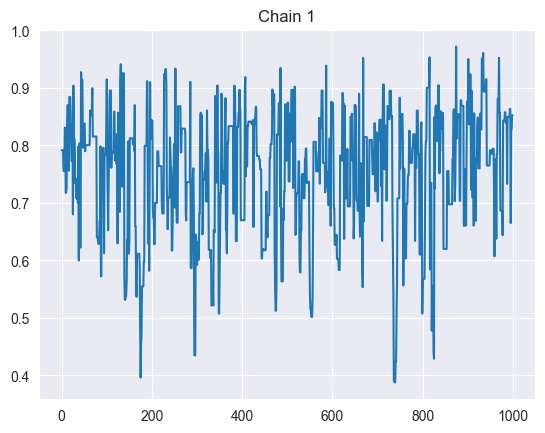

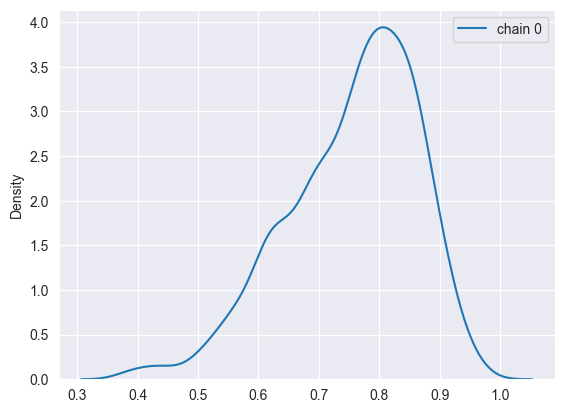

In [10]:
from scipy import stats
import seaborn as sns
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

def propose_jump(pi, sigma):
    return stats.norm.rvs( loc=pi, scale=sigma )

def decide(pi, pi2, alpha, beta, n, k, debug=False):
    # evaluate prior and likelihood
    prior1 = stats.beta.pdf( pi, alpha, beta )
    prior2 = stats.beta.pdf( pi2, alpha, beta )
    likelihood1 = stats.binom.pmf( n=n, k=k, p=pi )
    likelihood2 = stats.binom.pmf( n=n, k=k, p=pi2 )

    # define alpha
    alpha = min(1, prior2/prior1 * likelihood2/likelihood1)
    if debug: print("pi = {:.5f}, pi2 = {:.5f}, alpha = {:.5f}".format(pi, pi2, alpha))

    # jump decision
    p = np.random.rand()
    if p<=alpha and 0 < pi2 < 1:
        return pi2
    else:
        return pi

def metropolis_chain(n_steps, alpha, beta, n, k, sigma):
    # initialize
    pi = np.random.rand()
    chain = []

    # create chain
    for i in tqdm( range( n_steps ) ):
        pi2 = propose_jump( pi, sigma )
        pi = decide( pi, pi2, alpha, beta, n, k )
        chain.append( pi )

    return chain

def metropolis( n_chains, n_steps, alpha, beta, n, k, sigma ):
    res = [metropolis_chain( n_steps, alpha, beta, n, k, sigma ) for i in range( n_chains)]
    return np.array(res).T # to have chains in columns

def trace_plots(sim):
    for i in range( sim.shape[1] ):
        plt.figure()
        plt.plot( sim[:,i] )
        plt.title("Chain {}".format(i+1))

def density_plots( sim ):
    plt.figure()
    for i in range( sim.shape[1] ):
        sns.kdeplot( sim[:,i], label="chain {}".format(i) )
    plt.legend()

def rhat( sim ):
    total_var = np.var( sim.flatten() )
    individual_var = np.var( sim, axis=0 )
    rhat = np.sqrt( total_var / np.mean(individual_var) )
    return rhat

sim = metropolis(n_chains=1, n_steps=1000, alpha=5, beta=2, n=10, k=8, sigma=0.2)

trace_plots(sim)
density_plots(sim)
print(f"Rhat: {rhat(sim)}")

For target density $\pi(\theta) = p(\theta\mid d)$ and symmetric proposal distribution $q(\theta' \mid \theta)$, the Metropolis steps are:

1. **Initialize** $\theta^{(0)}$ (e.g. some reasonable value).
2. For iterations $t = 0,1,\dots$:
3. **Propose** new state $\theta' \sim q(\theta' \mid \theta^{(t)})$.
E.g. random walk: $q = \mathcal N(\theta^{(t)}, \sigma_{\text{prop}}^2)$.
4. **Compute acceptance probability** $\alpha = \min\left\{1,\;\frac{\pi(\theta')}{\pi(\theta^{(t)})}\right\} = \min\left\{1,\;\frac{p(d\mid \theta')p(\theta')}{p(d\mid \theta^{(t)})p(\theta^{(t)})}\right\}$
5. **Accept or reject**: Draw $u \sim \text{Uniform}(0,1)$, If $u < \alpha$, set $\theta^{(t+1)}=\theta'$ (move), Else set $\theta^{(t+1)}=\theta^{(t)}$ (stay).
6. After burn‑in and thinning, use remaining samples as approximate draws from the posterior.

**Proposal distribution**: the distribution from which proposed new parameters are drawn ($q(\theta' \mid \theta)$). Choice of its scale strongly affects mixing and acceptance rate.

## MCMC with PyMC

In [11]:
import pymc as pm
# PyMC for Beta-Binominal Conjugate Family
with pm.Model() as beta_binom_model:
    pi = pm.Beta("pi", alpha=5, beta=2)
    y = pm.Binomial("y", p=pi, n=10, observed=8)
    trace = pm.sample(1000)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [pi]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


In [12]:
import arviz as az
import pandas as pd

def uncertainty_binominal(trace_posterior, var_name: str, n: int, **kwargs):
    assert var_name != None, "var_name is required for pi"
    assert n != None and n > 0, "n must be > 0"

    values = trace_posterior[var_name].values
    aleatoric_var = (n * values * (1.0 - values)).mean()
    epistemic_var = (values * n).var(ddof=1)

    return aleatoric_var, epistemic_var

def uncertainty_normal(trace_posterior, mu: str = "mu", sigma: str = "sigma", **kwargs):
    aleatoric_var = (trace_posterior[sigma].values**2).mean()
    epistemic_var = trace_posterior[mu].var(ddof=1).values

    return aleatoric_var, epistemic_var

def uncertainty_poisson(trace_posterior, var_name: str, n: int, **kwargs):
    assert var_name != None, "var_name is required for lambda"

    values = trace_posterior[var_name].values
    aleatoric_var = values.mean()
    epistemic_var = values.var(ddof=1)

    return aleatoric_var, epistemic_var

def uncertainty_summary(trace_posterior, family=None, **kwargs):
    """
    Computes the aleatoric (data), epistemic (model uncertainty) and predictive (overall uncertainty) variance of a pymc trace.posterior

    Parameters
    ----------
    trace_posterior : array_like
        Array containing numbers whose mean is desired. If `a` is not an
        array, a conversion is attempted.
    family : str
        Either one of 'binominal', 'normal' or 'poisson'.

    For family='binominal':
    -----------------------
    var_name : str
        Name of the Pi variable in the trace_posterior
    n : int
        Number of trials

    For family='normal':
    -----------------------
    mu : str
        Name of the parameter that represents the mean of the normal distribution.

    sigma : str
        Name of the parameter that represents the standard deviation of the normal distribution.

    For family='poisson':
    -----------------------
    var_name : str
        Name of the lambda variable in the trace_posterior
    """
    assert trace_posterior != None, "trace_posterior must be provided"
    assert family != None, "family must be provided"

    uncertainty_stats = pd.DataFrame()
    match family:
        case 'binominal':
            aleatoric_var, epistemic_var = uncertainty_binominal(trace_posterior, **kwargs)
        case 'normal':
            aleatoric_var, epistemic_var = uncertainty_normal(trace_posterior, **kwargs)
        case 'poisson':
            aleatoric_var, epistemic_var = uncertainty_poisson(trace_posterior, **kwargs)
        case _:
            raise ValueError(f"Unknown family: {family}")

    predictive_var = aleatoric_var + epistemic_var

    uncertainty_stats[family] = {
        'var_aleatoric': aleatoric_var,
        'var_epistemic': epistemic_var,
        'var_predictive': predictive_var,
        'var_aleatoric_percent': aleatoric_var / predictive_var,
        'var_epistemic_percent': epistemic_var / predictive_var,
    }

    # switch rows and columns:
    uncertainty_stats = uncertainty_stats.T

    return uncertainty_stats

def trace_summary(trace, hdi_prob=0.8, var_names=None):
    # Use `var_names=['pi', ...]` to limit to vars of interest
    stats = az.summary(trace, hdi_prob=hdi_prob, var_names=var_names)

    # Variance = standard deviation ** 2:
    stats.insert(stats.columns.get_loc('sd') + 1, 'var', stats.sd ** 2)
    stats.insert(stats.columns.get_loc('mcse_sd') + 1, 'mcse_var', stats.mcse_sd ** 2)

    hdi_alpha = 1.0 - hdi_prob

    hdi_low = f'hdi_{100 * hdi_alpha / 2:g}%'
    hdi_high = f'hdi_{100 * (1 - hdi_alpha / 2):g}%'

    stats.insert(stats.columns.get_loc(hdi_high) + 1, 'hdi_low', stats[hdi_low])
    stats.insert(stats.columns.get_loc(hdi_high) + 2, 'hdi_high', stats[hdi_high])

    return stats

In [13]:
import pymc as pm
import arviz as az

# Data: k successes out of n trials
n = 40
k = 26

with pm.Model() as model:
    # Prior on probability pi
    pi = pm.Beta("pi", alpha=1.0, beta=1.0)  # flat prior

    # Likelihood
    y = pm.Binomial("y", n=n, p=pi, observed=k)

    # Sample with NUTS (HMC variant; more efficient than plain Metropolis)
    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42
    )

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [pi]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 0 seconds.


### Diagnosing convergence and mixing

Key visual and numeric diagnostics:

**Trace plots:** Plot each chain’s sampled values over iterations

![Trace Plot Diagnostic](bayesian-machine-learning/Trace-Plot-Diagnostic.png)

For Metropolis specifically, problematic trace plots often indicate: Proposal variance too small (tiny steps, high acceptance, poor exploration). Proposal variance too large (proposals rejected, chain rarely moves). Tunable by adjusting $\sigma_{\text{prop}}$.

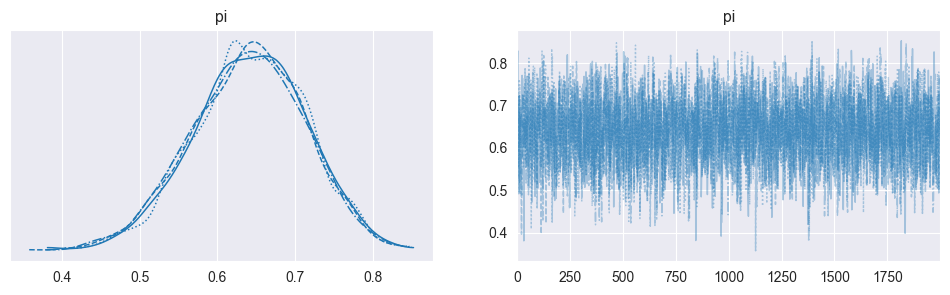

In [14]:
import arviz as az
az.plot_trace(trace, kind='trace', figsize=(12, 3))
plt.show()

Chains explore the same region (“fuzzy caterpillars”)

No systematic upward or downward drift.

No chains stuck in a narrow band.

Different chains overlap well.

**Run multiple chains:** Posterior histograms or kernel density estimates for each chain separately

![Run Multiple Chains Diagnostic Plot](bayesian-machine-learning/Run-Multiple-Chains-Plot.png)

Distributions from all chains almost perfectly overlap.

No unique behavior in one chain.

**Autocorrelation plots:** Autocorrelation function (ACF) of each chain as a function of lag

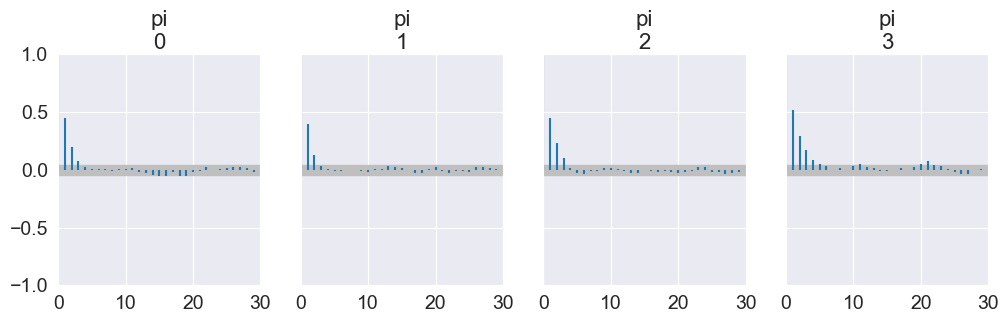

In [15]:
import arviz as az
import matplotlib.pyplot as plt
az.plot_autocorr(trace, max_lag=30, figsize=(12, 3))
plt.show()

Autocorrelation decays quickly with lag.

Very slow decay or persistent high correlation means poor mixing and low effective sample size.

**Rank plots / rank bars:** For each parameter, pool all samples from all chains, compute their ranks, then see how ranks are distributed per chain (as in ArviZ’s rank plots)

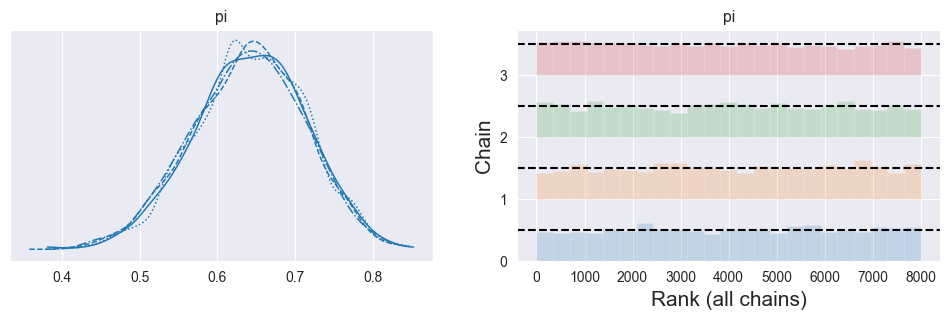

In [16]:
import arviz as az
import matplotlib.pyplot as plt
az.plot_trace(trace, kind='rank_bars', figsize=(12, 3))
plt.show()

Ranks within each chain are roughly uniformly distributed.

All chains show similar, flat-ish rank patterns.

Strong deviations (U‑shape, spikes, or clearly different patterns per chain) indicate non‑convergence or poor mixing.

**$\hat R$ (R‑hat, Gelman–Rubin statistic):** Compares total chain data variance (concatenated) vs. the mean variance within individual chains. Summarizes the overlaid density plots of multiple chains and provides a numerical measure for their diagreement.

$$
\hat{R} = \sqrt{\frac{\mathrm{Var}_{\text{total}}}{\mathrm{Var}_{\text{within}}}} = \sqrt{\frac{\mathrm{Var}(\{c_i\})}{\frac{1}{n_c}\sum_{i=1}^{n_c}\mathrm{Var}(c_i)}}
$$

In [17]:
trace_summary(trace)

,mean,sd,var,hdi_10%,hdi_90%,hdi_low,hdi_high,mcse_mean,mcse_sd,mcse_var,ess_bulk,ess_tail,r_hat
pi,0.641,0.073,0.005329,0.552,0.738,0.552,0.738,0.001,0.001,0.000001,3041.0,4233.0,1.0


**$\hat R \approx 1.00$** (e.g. < 1.01–1.05) means chains have likely converged to same target distribution.

**$\hat R > 1.05$** means potential non‑convergence; increase iterations, needs better initialization, or reparameterization.

**ESS (effective sample size):** Estimates how many *independent* draws your autocorrelated chain is equivalent to

In [18]:
trace_summary(trace)

,mean,sd,var,hdi_10%,hdi_90%,hdi_low,hdi_high,mcse_mean,mcse_sd,mcse_var,ess_bulk,ess_tail,r_hat
pi,0.641,0.073,0.005329,0.552,0.738,0.552,0.738,0.001,0.001,0.000001,3041.0,4233.0,1.0


ESS large relative to the number of draws, giving stable posterior summaries. **Rule of thumb: ESS / N > 10%**

Very small ESS (especially compared to total draws) means strong autocorrelation, poor mixing, unreliable summaries.

`ess_bulk` (Bulk ESS): Use this to assess reliability of posterior means, medians, and central credible intervals. Estimates the effective sample size for the central part of the distribution (around the median/mean). Interpretation: Higher is better. If `ess_bulk` is very small relative to the total number of draws, the chain is autocorrelated or has poor mixing in the center of the distribution.


`ess_tail` (Tail ESS): Use this to assess reliability of HDI/credible interval bounds and tail probabilities. Estimates the effective sample size specifically for the tails of the distribution (extreme quantiles, typically 5th and 95th percentiles). Interpretation: Higher is better. Can be substantially lower than `ess_bulk` if the tails are poorly explored.

# Posterior Summaries, Prediction, and Uncertainty

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [pi]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 0 seconds.


,mean,sd,var,hdi_10%,hdi_90%,hdi_low,hdi_high,mcse_mean,mcse_sd,mcse_var,ess_bulk,ess_tail,r_hat
pi,0.641,0.073,0.005329,0.552,0.738,0.552,0.738,0.001,0.001,0.000001,3041.0,4233.0,1.0


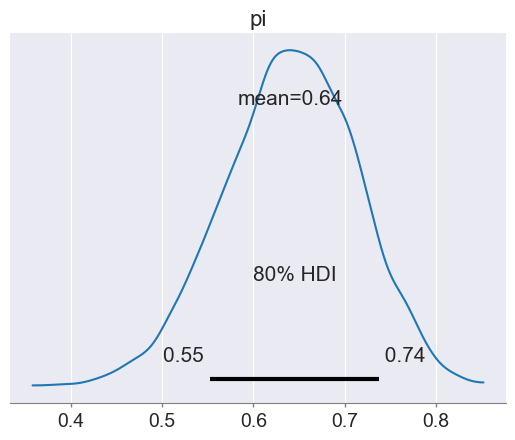

In [19]:
import pymc as pm
import arviz as az

# Data: k successes out of n trials
n = 40
k = 26

with pm.Model() as model:
    pi = pm.Beta("pi", alpha=1.0, beta=1.0)  # Prior on probability pi
    y = pm.Binomial("y", n=n, p=pi, observed=k) # Likelihood
    trace = pm.sample( # Sample posterior
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42
    )

az.plot_posterior(trace, hdi_prob=0.80) # Posterior plot: shows density + HDI interval + mean
trace_summary(trace, hdi_prob=0.80)

## Point Summaries: Mean, Variance, Maximum A Posteriori (MAP / Posterior Mode)

In [20]:
stats = trace_summary(trace)
stats # Use `stats.loc['pi']['mean']` to access specific values

,mean,sd,var,hdi_10%,hdi_90%,hdi_low,hdi_high,mcse_mean,mcse_sd,mcse_var,ess_bulk,ess_tail,r_hat
pi,0.641,0.073,0.005329,0.552,0.738,0.552,0.738,0.001,0.001,0.000001,3041.0,4233.0,1.0


Given posterior samples $\theta_1,\dots,\theta_N$:

**Posterior mean:** $\hat\theta_{\text{mean}} = \frac{1}{N}\sum_{i=1}^N \theta_i$

**Posterior variance:** $\widehat{\text{Var}}(\theta) = \frac{1}{N-1}\sum_{i=1}^N(\theta_i - \hat\theta_{\text{mean}})^2$

**Maximum A Posteriori (MAP) or Posterior Mode:** $\hat{\theta}_{\text{MAP}}=\arg\max_{\theta} P(\theta \mid D) = \arg\max_{\theta} P(D\mid\theta) P(\theta) = \log P(D\mid\theta) + \log P(\theta)$;
To compute: Use closed form Posterior Mode if available; or Differentiate with respect to $\theta$, set the derivative to zero, and solve for $\theta$; or use numerical optimization when there is no closed form.

## Credible Intervals vs. Confidence Intervals

<>:57: SyntaxWarning: invalid escape sequence '\h'
<>:57: SyntaxWarning: invalid escape sequence '\h'
/var/folders/mg/f7gk10vj1_153rz1zkvd13_00000gn/T/ipykernel_51746/77079293.py:57: SyntaxWarning: invalid escape sequence '\h'
  plt.axvline(p_hat, color="blue", linestyle="--", label="Sample proportion $\hat p$")
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [pi]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 0 seconds.


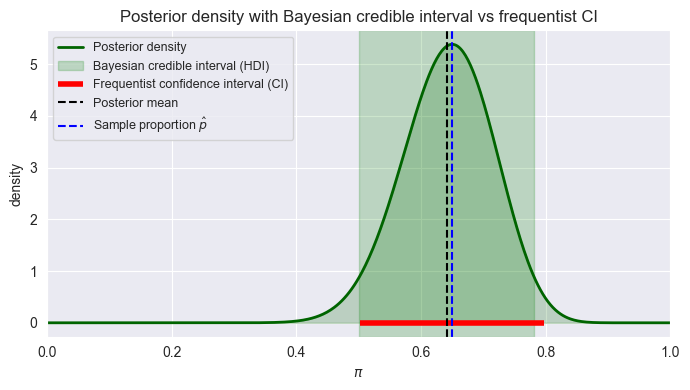

In [21]:
import numpy as np
import pymc as pm
import matplotlib.pyplot as plt
from scipy.stats import beta
from statsmodels.stats.proportion import proportion_confint

pi_x = np.linspace(0, 1, 500)

# Data: k successes out of n trials
n = 40
k = 26
p_hat = k / n

# Prior parameters: Beta(1,1) -> flat
alpha_prior = 1.0
beta_prior = 1.0

# Posterior parameters
alpha_posterior = alpha_prior + k
beta_posterior  = beta_prior + n - k
pi_y = beta.pdf(pi_x, a=alpha_posterior, b=beta_posterior)

with pm.Model() as model_binom:
    pi = pm.Beta("pi", alpha=alpha_prior, beta=beta_prior) # Prior on probability pi
    y = pm.Binomial("y", n=n, p=pi, observed=k) # Likelihood
    trace = pm.sample( # Sample posterior
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42
    )

stats = trace_summary(trace, hdi_prob=0.95, var_names=['pi'])
ci_low, ci_high = proportion_confint(k, n, alpha=0.05)

# print(f"Posterior mean (pi)                  = {stats.loc['pi']['mean']:.4f}")
# print(f"Bayesian credible interval (HDI)     = {[stats.loc['pi']['hdi_low'], stats.loc['pi']['hdi_high']]}")
# print(f"Frequentist confidence interval (CI) = {[ci_low, ci_high]}")

plt.figure(figsize=(7, 4))

# Posterior density
def plot_density(x, y, label, color='darkgreen'):
    plt.plot(x, y, label=label, lw=2, color=color)
    plt.fill_between(x, y, alpha=0.2, color=color)
plot_density(pi_x, pi_y, label="Posterior density")

# Shade Bayesian credible interval (HDI)
plt.axvspan(stats.loc['pi']['hdi_low'], stats.loc['pi']['hdi_high'], color="green", alpha=0.2, label="Bayesian credible interval (HDI)")

# Mark frequentist CI as a horizontal bar at y=0
plt.hlines(y=0.0,xmin=ci_low,xmax=ci_high,colors="red",linewidth=4,label="Frequentist confidence interval (CI)")

# Mark posterior mean and p_hat
plt.axvline(stats.loc['pi']['mean'], color="k", linestyle="--", label="Posterior mean")
plt.axvline(p_hat, color="blue", linestyle="--", label="Sample proportion $\hat p$")

plt.xlim(0, 1)
plt.xlabel(r"$\pi$")
plt.ylabel("density")
plt.title("Posterior density with Bayesian credible interval vs frequentist CI")
plt.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

**Credible interval (Bayesian)**: For posterior $p(\theta\mid d)$, an **80% credible interval** $[a,b]$ satisfies: $P(a \le \theta \le b \mid d) = 0.8$. It's a direct statement about the parameter: "Given data and model, we believe with 80% plausibility that $\theta$ lies in $[a,b]$."

**HDI (Highest Density Interval)**: Among all 80% intervals, choose the one where posterior density is everywhere at least as high as outside. It minimizes width for a given mass; It contains the most probable values by construction.

**Confidence interval (frequentist)**: 80% CI: in 80% of repeated experiments, the interval constructed by a given procedure will contain the *fixed* true $\theta$. It does *not* allow the statement "$\theta$ is in this specific interval with probability 0.8".

## Aleatoric vs. Epistemic Uncertainty

**Law of total variance:**

$$
\text{Var}(Y_{\text{new}}\mid d)
= \underbrace{\mathbb E_{\theta\mid d}[\text{Var}(Y_{\text{new}}\mid \theta)]}_{\text{aleatoric}}
+ \underbrace{\text{Var}_{\theta\mid d}\big(\mathbb E[Y_{\text{new}}\mid \theta]\big)}_{\text{epistemic}}
$$

**Aleatoric Uncertainty**: irreducible data noise (e.g. binomial or Gaussian observation noise).

**Epistemic Uncertainty**: uncertainty about model parameters; reducible with more/better data.

**If Epistemic is bigger than Aleatoric**, it means collecting more data can meaningfully reduce predictive uncertainty.

**If Aleatoric is bigger than Epistemic**, it means that even infinite data cannot substantially reduce predictive spread (inherent randomness).

In [22]:
uncertainty_summary(trace.posterior, family='binominal', n=n, var_name='pi')
# uncertainty_summary(trace.posterior, family='normal', mu='mu', sigma='sigma')
# uncertainty_summary(trace.posterior, family='poisson', var_name='lambda')

,var_aleatoric,var_epistemic,var_predictive,var_aleatoric_percent,var_epistemic_percent
binominal,8.998737,8.447442,17.44618,0.5158,0.4842


In [23]:
# Double check with posterior predictive:

var_name = 'y'
with model:
    predictions = pm.sample_posterior_predictive(trace, var_names=[var_name], random_seed=42)
predictive_var = predictions.posterior_predictive[var_name].var(ddof=1).values

print(f"Predictive Variance = {predictive_var} (for {predictions.posterior_predictive.y.values.size} samples)")
trace_summary(predictions.posterior_predictive, var_names=[var_name])

Sampling: [y]


Predictive Variance = 17.244173631078883 (for 8000 samples)


,mean,sd,var,hdi_10%,hdi_90%,hdi_low,hdi_high,mcse_mean,mcse_sd,mcse_var,ess_bulk,ess_tail,r_hat
y,25.621,4.153,17.247409,20.0,30.0,20.0,30.0,0.062,0.037,0.001369,4417.0,5763.0,1.0


# Hypothesis Testing

Many branches of science depend on hypothesis testing to build knowledge. Hypothesis tests are often used for feature selection (e.g. t-test p-value for features in frequentist linear regression). In Bayesian statistics, one method for model selection is based on hypothesis testing (a model is a hypothesis).

## Frequentist vs. Bayesian Hypothesis Tests

**Frequentist hypothesis testing** can only compute the probability of data under a given hypothesis. Set up a null hypothesis and discard it if the probability $P(d \mid H_0)$ is too low. This approach is dangerous when we measure unlikely data or are looking at unlikely hypotheses.

**Bayesian hypothesis testing** can compute $P(H \mid d)$, i.e. our posterior belief in $H$ given data $d$! Does not need a null hypothesis - can compare any two or more competing hypotheses! Bayesian and frequentist hypothesis tests return different results whenever there is heavy prior belief in $H_0$ and we have measured unlikely data that are in favor of $H_1$: The Bayesian approach is more robust in this case because it supports the philosophy of "one random accident should not overthrow an established theory".

## One-Sided Hypothesis Tests

**Frequentist Hypothesis Test: Null Hypothesis Significance Testing (NHST)**

1. Define $H_0$ and $H_1$
2. Define an estimator $\hat\pi$ and significance level $\alpha$ (false positive rate, usually $\alpha = 0.05$)
3. Define a test statistic (i.e. z-score in case of binominal distribution, type of test statistic depends on estimator!): $z = \frac{\hat\pi - \pi_0}{\sigma} = \frac{\hat\pi - \pi_0}{\sqrt{\frac{\hat\pi_0(1-\hat\pi_0)}{n}}}$
4. Determine p-value: $p = P(Z > z) = 1 - \Phi(z)$
5. If $p < \alpha$, reject $H_0$$

**Bayesian Hypothesis Test: Compare posterior probability of hypotheses**

![Bayesian Hypothesis Testing](bayesian-machine-learning/Bayesian-Hypothesis-Testing.png)

1. Define $H_0$ and $H_1$:
   - $H_0:$ 80% of people or less in the local population are able to roll their tongue
   - $H_1:$ More than 80% of people in the local population are able to roll their tongue
2. Define a prior distribution for $\pi$ (e.g. Beta(1,1) for flat prior)
3. Define a likelihood function (e.g. Binomial likelihood)
4. Sample posterior $\pi_i$
5. Approximate posterior distribution of $\pi$ using $H_0$ and $H_1$

```python
pH1d = np.mean(trace.posterior.pi.values > 0.8)
pH1d, 1.0 - pH1d
```

In [24]:
# With posterior samples pi_i, approximate:
import numpy as np
import pymc as pm

# Data: k successes out of n trials
n = 40
k = 26

with pm.Model() as one_sided_model:
    # Prior on pi: flat Beta(1,1)
    pi = pm.Beta("pi", alpha=1.0, beta=1.0)

    # Likelihood
    y = pm.Binomial("y", n=n, p=pi, observed=k)

    # Sample posterior
    trace = pm.sample(
        draws=3000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42
    )

# Extract posterior samplesd
pi_samples = trace.posterior["pi"].values.flatten()

# Posterior probability of H1: pi > 0.8
P_H1_post = np.mean(pi_samples > 0.8)
P_H0_post = 1.0 - P_H1_post

print(f"P(H1: pi > 0.8 | data)      = {P_H1_post:.3f}")
print(f"P(H0: pi ≤ 0.8 | data)      = {P_H0_post:.3f}")
print(f"Posterior odds H1:H0        = {P_H1_post / P_H0_post:.3f}")

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [pi]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.


P(H1: pi > 0.8 | data)      = 0.010
P(H0: pi ≤ 0.8 | data)      = 0.990
Posterior odds H1:H0        = 0.010


## Bayes Factor and Odds

In [25]:
# Prior probabilities under Beta(1,1)
P_H0_prior = 0.8
P_H1_prior = 1.0 - P_H0_prior  # P(pi > 0.8) for uniform prior = 0.2

prior_odds = P_H1_prior / P_H0_prior
post_odds  = P_H1_post / P_H0_post

BF_10 = post_odds / prior_odds

print(f"Prior Odds H1:H0            = {prior_odds:.3f}")
print(f"Posterior Odds H1:H0        = {post_odds:.3f}")
print(f"Bayes Factor BF_10          = {BF_10:.3f}")

Prior Odds H1:H0            = 0.250
Posterior Odds H1:H0        = 0.010
Bayes Factor BF_10          = 0.040


**Prior odds** for $H_1$ vs $H_0$ (how much more likely is $H_1$ than $H_0$): $\frac{P(H_1)}{P(H_0)}$, flip the ratio if you are interested in how much more likely is $H_0$ than $H_1$

**Posterior odds** after data: $\frac{P(H_1\mid d)}{P(H_0\mid d)}$

**Bayes factor** $BF = \frac{P(d\mid H_1)}{P(d\mid H_0)} = \frac{\text{posterior odds}}{\text{prior odds}}$, describes how much my believe changed or how much I learned from the data. Rules of Thumb: 1–3: barely worth mentioning, 3–10: substantial, 10–100: strong, bigger than 100: decisive evidence in favour of $H_1$.

## Two-Sided Hypothesis Tests

### Region of Practical Equivalence (ROPE)

In Bayesian inference, testing whether a parameter exactly equals a specific value is statistically problematic because the probability of a continuous parameter equaling any single point is essentially zero. Instead, ROPE defines a range of values considered "practically equivalent" to the null hypothesis. For testing whether a parameter is *practically equal* to some value $\pi_0$, define a **ROPE**, e.g. $[\pi_0-\delta, \pi_0+\delta]$.

![Two Sided Bayesian Hypothesis Test](bayesian-machine-learning/Bayesian-Hypothesis-Test-Two-Sided.png)

- $H_0$: Exactly 93% of people in the local population are able to roll their tongue $\implies \pi_0 \in [\pi_0-\delta,\pi_0+\delta]$ for $\pi_0 = 0.93$ and some $\delta > 0$.
- $H_1$: More or less than 93% of people in the local population are able to roll their tongue $\implies \pi_0$ outside that interval.

```python
pi0 = 0.93; delta = 0.03
pi_values = trace.posterior.pi.values
pH0d = np.mean((pi_values > pi0 - delta) &
    (pi_values < pi0 + delta))
pH1d = 1 - pH0d
pH0d, pH1d, (pH0d / pH1d)
```

If most posterior mass lies inside the ROPE, you accept *practical equivalence*; otherwise, you conclude a meaningful difference. If the posterior distribution is fairly diffuse, with substantial mass both inside and outside this range a narrow ROPE {small $\delta$) can create an inconclusive result. A larger ROPE (bigger $\delta$) reflects what differences you actually care about practically: If you only need to know whether the true proportion is "around 93%" rather than "exactly 93%", a wider ROPE makes sense.

## Posterior Predictive Checks

1. Fit model and obtain posterior samples.
2. For each posterior draw, simulate an entire *replicated* dataset from the model (posterior predictive).
3. Compare distribution of replicated data to observed data (histograms, kernel density plots, summary statistics).

If simulated data systematically differ (e.g. lower variance, wrong tail behaviour), the model is likely misspecified (e.g. wrong likelihood family).

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sales_sigma, Intercept, TV, radio, TV:radio]


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 4 seconds.


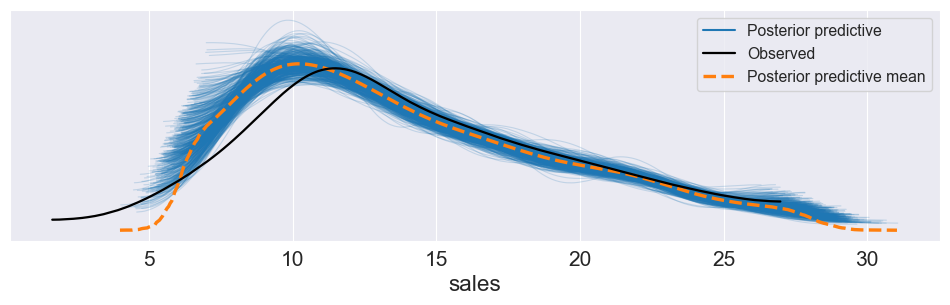

In [26]:

import bambi as bmb
import pandas as pd
import numpy as np
import arviz as az
import matplotlib.pyplot as plt

data = pd.read_csv("bayesian-machine-learning/advertising.csv")
model = bmb.Model( "sales ~ TV + radio + TV:radio", data=data, family="gaussian" )
trace = model.fit(draws=2000, tune=2000, chains=4, target_accept=0.9, random_seed=42)
model.predict(trace, kind="pps")
az.plot_ppc(trace, num_pp_samples=500, figsize=(12, 3))
plt.show()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [pi]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.


ROPE = [0.65, 0.70]
P(H0: pi in ROPE | data)    = 0.245
P(H1: pi outside ROPE | data) = 0.755
Posterior odds H0:H1        = 0.324


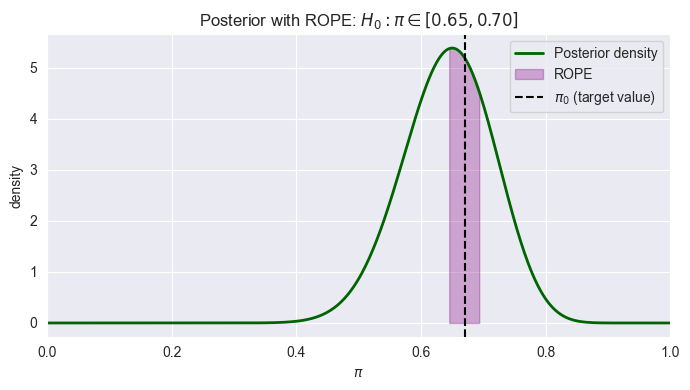

In [27]:
import numpy as np
import pymc as pm

# Data: k successes out of n trials
n = 40
k = 26

alpha_prior, beta_prior = 1.0, 1.0

with pm.Model() as one_sided_model:
    # Prior on pi: flat Beta(1,1)
    pi = pm.Beta("pi", alpha=alpha_prior, beta=beta_prior)

    # Likelihood
    y = pm.Binomial("y", n=n, p=pi, observed=k)

    # Sample posterior
    trace = pm.sample(
        draws=3000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42
    )

# Extract posterior samplesd
pi_samples = trace.posterior["pi"].values.flatten()

###################################################
# Compute posterior mass in ROPE and posterior odds
###################################################

# Define ROPE
pi0 = 0.67
delta = 0.025
rope_low  = pi0 - delta
rope_high = pi0 + delta

# Posterior probabilities
P_H0_rope = np.mean((pi_samples >= rope_low) & (pi_samples <= rope_high))
P_H1_rope = 1.0 - P_H0_rope

print(f"ROPE = [{rope_low:.2f}, {rope_high:.2f}]")
print(f"P(H0: pi in ROPE | data)    = {P_H0_rope:.3f}")
print(f"P(H1: pi outside ROPE | data) = {P_H1_rope:.3f}")
print(f"Posterior odds H0:H1        = {P_H0_rope / P_H1_rope:.3f}")

#######################################
# Visualize posterior with ROPE shaded
#######################################
from scipy.stats import beta

alpha_posterior, beta_posterior = alpha_prior + k, beta_prior + n - k
pi_grid = np.linspace(0, 1, 500)
post_pdf = beta.pdf(pi_grid, a=alpha_posterior, b=beta_posterior)

plt.figure(figsize=(7, 4))

# Posterior density
plt.plot(pi_grid, post_pdf, color="darkgreen", lw=2, label="Posterior density")

# Shade ROPE region
mask_rope = (pi_grid >= rope_low) & (pi_grid <= rope_high)
plt.fill_between(pi_grid[mask_rope], post_pdf[mask_rope], color="purple", alpha=0.3, label="ROPE")

# Vertical line at pi0
plt.axvline(pi0, color="k", linestyle="--", label=r"$\pi_0$ (target value)")

plt.xlabel(r"$\pi$")
plt.ylabel("density")
plt.xlim(0, 1)
plt.title(r"Posterior with ROPE: $H_0: \pi \in [{:.2f}, {:.2f}]$".format(rope_low, rope_high))
plt.legend()
plt.tight_layout()
plt.show()

## Model Checking, Selection, and Multivariate Distributions

## Model selection criteria

**The Fully Bayesian way**: Use Bayes Factor (based on marginal likelihood). This is conceptually clean, but marginal likelihood can be hard to compute.

**Use Predictive Criteria instead**: These criteria trade off **fit** vs **complexity**; Bayesian evidence automatically penalizes overly complex models ("built-in Occam’s razor").
- RMSE, MAE (point prediction error using posterior predictive means)
- ELPD / LOO (Expected Log Predictive Density with leave-one-out cross-validation, Computed with PSIS-LOO, higher is better)
- Bayesian $R^2$ for regression

# Bayesian Linear Regression

What is the posterior distribution of the linear regression parameters $\beta_0$, $\beta_1$, and $\sigma$? Use Bayes' theorem (and condition on $\mathbf{x}$):

$$p(\beta_0, \beta_1, \sigma \mid \mathbf{y}, \mathbf{x}) = \frac{p(\mathbf{y} \mid \beta_0, \beta_1, \sigma, \mathbf{x}) \, p(\beta_0, \beta_1, \sigma \mid \mathbf{x})}{p(\mathbf{y} \mid \mathbf{x})}$$

- **Likelihood**: $p(\mathbf{y} \mid \beta_0, \beta_1, \sigma, \mathbf{x})$ — probability of observing the data given parameters
- **Prior**: $p(\beta_0) p(\beta_1) p(\sigma)$ — treat parameters as independent, no direct dependence on $\mathbf{x}$
- **Evidence**: $p(\mathbf{y} \mid \mathbf{x})$ — marginal likelihood computed via MCMC

Then define priors and likelihood distributions:

$$
\begin{align}
\beta_0 &\sim N(\theta_0, \tau_0^2) \\
\beta_1 &\sim N(\theta_1, \tau_1^2) \\
\sigma &\sim \text{Exp}(1/l) \\
y \mid \beta_0, \beta_1, \sigma, x &\sim N(\beta_0 + \beta_1 x, \sigma^2)
\end{align}
$$

## Probabilistic Graphical Model Notation

Compact graphical way to describe a model without the distributions of the individual variables. Every unobserved variable that has no arrows going into it does need a prior. Bayesian inference will get us probability  distributions for the unobserved variables.

![Probabilistic Graphical Model Notation](bayesian-machine-learning/Probabilistic-Graphical-Model-Notation.png)

## Implementation and interpretation (PyMC/Bambi)

:::{figure} bayesian-machine-learning/Bambi-Operators.png
Built-in Bambi Operators
:::

In [31]:
import bambi as bmb
import pandas as pd
import arviz as az

In [39]:
data = pd.read_csv("bayesian-machine-learning/bodyfat.csv")
model = bmb.Model("BodyFat ~ 1 + BMI",
          data=data, family="gaussian")
trace = model.fit(draws=1000, tune=1000)
trace_summary(trace, hdi_prob=0.95)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [BodyFat_sigma, Intercept, BMI]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


,mean,sd,var,hdi_2.5%,hdi_97.5%,hdi_low,hdi_high,mcse_mean,mcse_sd,mcse_var,ess_bulk,ess_tail,r_hat
Intercept,-22.875,2.602,6.770404,-27.691,-17.672,-27.691,-17.672,0.034,0.038,0.001444,6019.0,2993.0,1.0
BMI,1.653,0.101,0.010201,1.456,1.843,1.456,1.843,0.001,0.001,0.000001,6091.0,3364.0,1.0
BodyFat_sigma,5.772,0.261,0.068121,5.270,6.268,5.270,6.268,0.003,0.004,0.000016,6699.0,3103.0,1.0


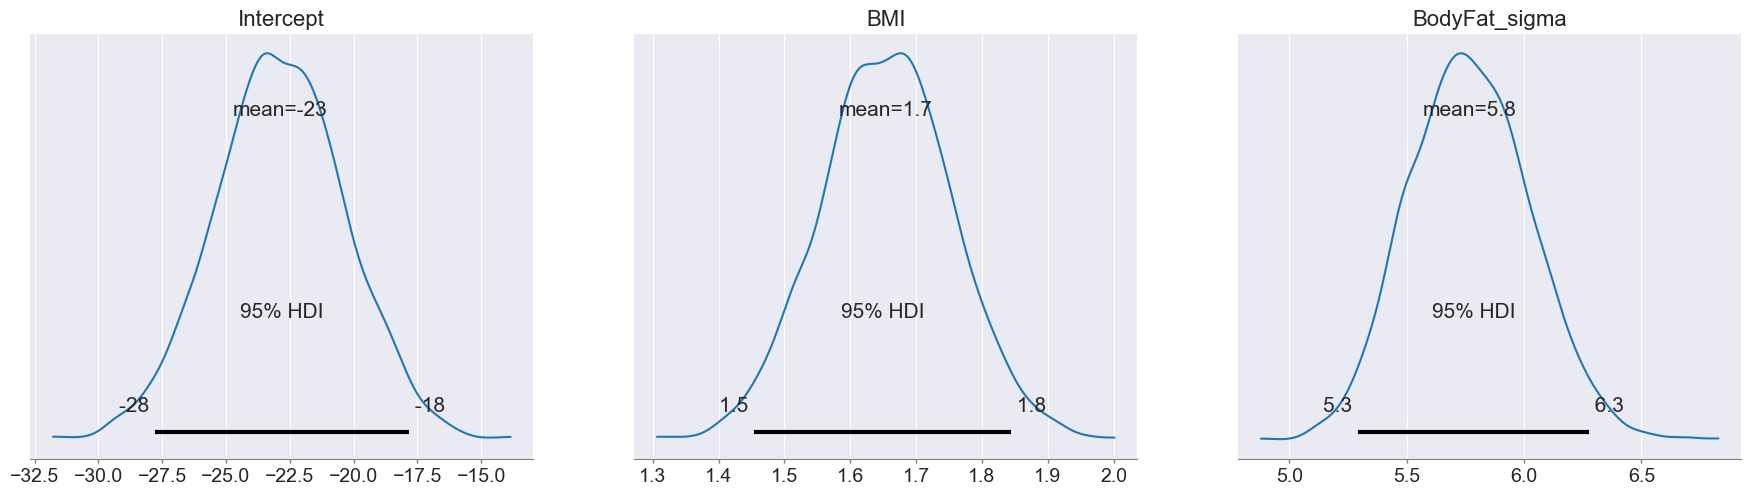

In [34]:
az.plot_posterior(trace, hdi_prob=0.95)
plt.show()

/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/arviz/rcparams.py:368: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(


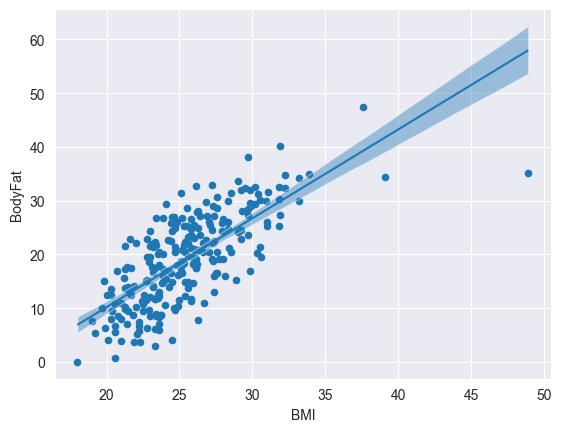

In [29]:
data.plot.scatter(x='BMI', y='BodyFat')
bmb.interpret.plot_predictions(
    model, trace, 'BMI', ax=plt.gca())
plt.show()

In [110]:
# predict out-of-sample data. for in-sample remove `data=...`
predictions = model.predict(trace, data=pd.DataFrame({ 'BMI': [20, 30, 50] }), kind="pps", inplace=False)
uncertainty_summary(predictions.posterior, family='normal', mu='BodyFat_mean', sigma='BodyFat_sigma')

,var_aleatoric,var_epistemic,var_predictive,var_aleatoric_percent,var_epistemic_percent
normal,33.390066,427.65162925057547,461.041696,0.072423,0.927577


In [114]:
predictions.posterior_predictive.BodyFat.var().values # double check posterior predictive variance

array(463.07425281)

## Robust Linear Regression

**Motivation:** Outliers can have a big impact on the resulting regression line.

**Reason:** The Gaussian likelihood does not like points far away from its center.

**Solution:** Can be mitigated using a Student's t-distribution with a heavier tail. Bayesians often prefer to change the likelihood instead of the data because its more reproducible.

In [40]:
model_robust = bmb.Model("BodyFat ~ BMI",
                    data=data, family="t")
trace_robust = model.fit(draws=1000, tune=1000)
trace_summary(trace_robust, hdi_prob=0.95)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [BodyFat_sigma, Intercept, BMI]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


,mean,sd,var,hdi_2.5%,hdi_97.5%,hdi_low,hdi_high,mcse_mean,mcse_sd,mcse_var,ess_bulk,ess_tail,r_hat
Intercept,-22.912,2.612,6.822544,-27.712,-17.630,-27.712,-17.630,0.034,0.040,0.001600,5755.0,3161.0,1.0
BMI,1.655,0.102,0.010404,1.449,1.844,1.449,1.844,0.001,0.002,0.000004,5862.0,3112.0,1.0
BodyFat_sigma,5.774,0.259,0.067081,5.317,6.330,5.317,6.330,0.003,0.004,0.000016,6154.0,3209.0,1.0


# Gaussian Processes (GPs)

## Intuition and definition

Gaussian Processes are prior distributions over functions: $f(x) \sim \mathcal{GP}(m(x), k(x,x'))$. A Gaussian Process **is fully characterized by: Mean $m(x) = E[f(x)]$ and a Covariance function $k(x,x') = cov[f(x), f(x')]$**

**Covariance function $k(x,x')$ must be:** Symmetric and Positive semi-definite: for any finite set of inputs, the matrix $K$ must produce non-negative quadratic forms $z^\top K z \ge 0$. If using a "kernel" that is *not* positive semi-definite (e.g. $K(x,x') = 2 + |x-x'|$), you can obtain **negative predictive variances** in the formula $v - k^\top C^{-1}k$. Such a function is **not** a valid covariance function, because a covariance matrix must be positive semi-definite, implying predictive variance must be $\ge 0$.

**Key Intuition about Gaussian Processes:** If things are close to each other, they should behave similar (i.e. be stronger correlated). That implies that the covariance between outputs is given in terms of the inputs.

**Conditioning Rule:** ("whats the prediction given the training data") $p(f_* \mid f) = \mathcal{N}\left(f_* \mid K_{f_* f} K_{ff}^{-1} f, K_{f_* f_*} - K_{f_* f} K_{ff}^{-1} K_{f_* f}^T\right)$

**Posterior Distribution for $f_*$ given $y$, including observation noise:**

$$
\begin{align}
p(f_* \mid y) &= \mathcal{N}(f_* \mid \mu_*, \sigma_*^2) \\
\mu_* &= K_{f_* f}(K_{ff} + \sigma_{\text{obs}}^2 I)^{-1} y \\
\sigma_*^2 &= K_{f_* f_*} - K_{f_* f}(K_{ff} + \sigma_{\text{obs}}^2 I)^{-1} K_{f_* f}^T
\end{align}
$$

Inverting the covariance matrix of the noisy observations $C = (K_{ff} + \sigma^2_{obs}I) \in \mathbb{R}^{n \times n}$ is the most computationally expensive step, resulting in a complexity of $O(N^3)$. Therefore, large datasets are challenging for standard GPs.

### GP regression: predictive mean and variance

/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianProcessRegressor was fitted with feature names
  warnings.warn(


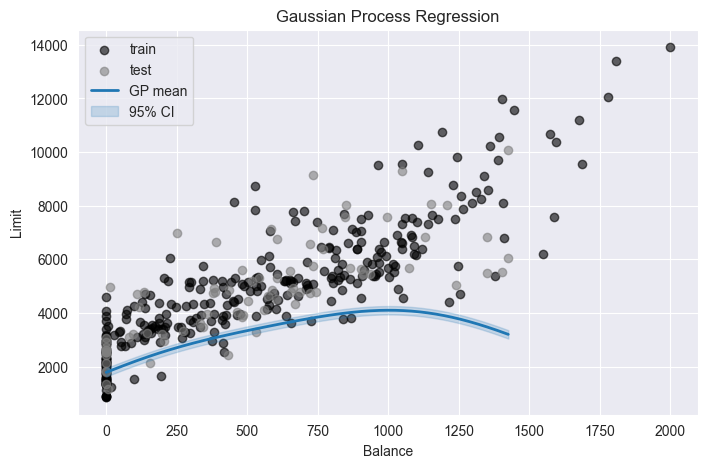

In [191]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.model_selection import train_test_split

length_scale = 300.0
variance = 100.0
sigma_obs = 80  # observation noise std

df = pd.read_csv("bayesian-machine-learning/credit_data.csv")
X_train, X_test, y_train, y_test = train_test_split(
    df[['Balance']],
    df[['Limit']],
    test_size=0.2,      # 20% test, 80% train
    random_state=42,    # for reproducibility
    shuffle=True        # default; set False if time series
)

kernel = variance * RBF(length_scale=length_scale) + WhiteKernel(noise_level=sigma_obs**2)
gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.0, optimizer=None, normalize_y=False)
gpr.fit(X_train, y_train)

X_plot = np.linspace(X_test["Balance"].min(), X_test["Balance"].max(), 400).reshape(-1, 1)
y_mean, y_std = gpr.predict(X_plot, return_std=True)

# ---- Plot ----
plt.figure(figsize=(8, 5))

# Training and test points
plt.scatter(X_train["Balance"], y_train, color="k", alpha=0.6, label="train")
plt.scatter(X_test["Balance"],  y_test,  color="gray", alpha=0.6, label="test")

# GP mean and 95% interval
plt.plot(X_plot[:, 0], y_mean, color="C0", lw=2, label="GP mean")
plt.fill_between(
    X_plot[:, 0],
    y_mean - 1.96 * y_std,
    y_mean + 1.96 * y_std,
    color="C0",
    alpha=0.2,
    label="95% CI"
)

plt.xlabel("Balance")
plt.ylabel("Limit")
plt.title("Gaussian Process Regression")
plt.legend()

**Predictive distribution for response $y_*$**:

$$
\mathbb E[y_* \mid x_*,\text{data}] = k^\top C^{-1} y \quad \text{Var}(y_* \mid x_*,\text{data}) = v - k^\top C^{-1}k
$$

- Training outputs $y \in \mathbb R^N$.
- Covariance matrix **for training outputs (including noise)**: $C = K_{ff} + \sigma_{\text{obs}}^2 I = k(X, X) + \sigma_{\text{obs}}^2 I$
- Covariances **between test point and training points**: $k = k(x_*, X) \in \mathbb R^N$
- **Prior variance at test point** (for $y_*$): $v = k(x_*,x_*) + \sigma_{\text{obs}}^2$

### Connection to kernels and PSD requirement

Common kernels and hyperparameters:

- **Squared Exponential / RBF**: $k(x,x') = \alpha \exp\left(-\frac{\|x-x'\|^2}{2\ell^2}\right)$, ($\alpha$: output variance, $\ell$: length scale (smoothness))
- **Matérn** (controls differentiability via $\nu$):
- **Rational Quadratic** (mixture over length scales).

# Bayesian Networks and Causal Inference

## Structural Causal Models (SCMs) and Bayesian Networks

SCM formalism (from BN lecture notes):

- Endogenous (ovservered) variables $V$: determined by structural equations.
- Exogenous (unobserved) variables $U$: external noise.
- Structural equations: each variable $V_i$ is a function of its parents (endogenous causes) and noise (exogenous causes):

$$
V_i = f_i(\text{Pa}_i, U_i)
$$

- Joint distribution defined via $P(U)$ and structural equations.

A **Bayesian Network (BN)** is a DAG over variables $V$ such that joint distribution factorizes as:

$$
p(v_1,\dots,v_n) = \prod_{i=1}^n p(v_i \mid \text{Pa}_i).
$$

- Graph encodes conditional independencies.
- Each node has a Conditional Probability Table (CPT) or parameterized distribution.

## Basic graph motifs and conditional independence

Three canonical patterns:

1. **Chain (serial)**: $X \to Z \to Y$
    - $X$ and $Y$ correlated marginally.
    - Conditional independence given the middle node: $X \perp Y \mid Z$.
2. **Fork (common cause)**: $X \leftarrow Z \to Y$
    - $X$ and $Y$ correlated marginally (through common cause $Z$).
    - Conditional independence given cause: $X \perp Y \mid Z$.
3. **Collider (v‑structure)**: $X \to Z \leftarrow Y$
    - $X$ and $Y$ *independent* marginally.
    - Conditioning on collider (or its descendants) *induces dependence* (explaining away).
    - **Explaining away**: In collider $X \to Z \leftarrow Y$, observing the effect $Z$ makes causes $X$ and $Y$ compete.
      - Example: “Smoker” and “Covid” both cause “Hospitalization”; given hospitalization, learning that patient is a smoker reduces belief that Covid is cause, and vice versa.

## Computing Probabilities from Joint Tables

Given full joint distribution table $P(H,S,C)$:

$$
\begin{array}{c|c|c|c}
s & c & h & \mathbb{P}(H = h, S = s, C = c) \\
\hline
0 & 0 & 0 & 0.75597 \\
0 & 0 & 1 & 0.03993 \\
\dots & \dots & \dots & \dots \\
\end{array}
$$

_Marginal_: $P(C=1) = \sum_{s,h} P(C=1, H=h, S=s) = P(C=1, H=0, S=0) + P(C=1, H=0, S=1) + \dots$

_Conditional_: $P(C=1 \mid H=1) = \dfrac{\sum_s P(C=1,H=1,S=s)}{\sum_{c,s}P(C=c,H=1,S=s)}$

**Example:** $P(C = 1 \mid H = 1, S = 0) = \dfrac{P(C = 1, H = 1, S = 0)}{P(H = 1, S = 0)} = \dfrac{P(C = 1, H = 1, S = 0)}{\sum_c P(C = c, H = 1, S = 0)}$


## Interventions and the do‑operator

**Conditioning**: $P(Y\mid X=x)$ describes correlations in observed data; $X$ may itself be caused by other variables (confounded).

**Intervention**: $P(Y\mid \text{do}(X=x))$ describes what happens if we *force* $X$ to $x$ (surgery on the graph):

- All incoming edges into $X$ are cut.
- $X$ is set externally.
- The rest of the graph and conditional distributions remain unchanged.

For a treatment $X$, outcome $Y$, and set of observed confounders $Z$ that block all backdoor paths (backdoor criterion), **adjustment formula**:

$$
P(Y\mid \text{do}(X=x)) = \sum_z P(Y\mid X=x, Z=z)\,P(Z=z).
$$

## Expectation Maximization (EM)

The EM algorithm iteratively maximizes the log-likelihood of the observed data. $H$ is hidden, $E = e$ is observed.

1. Initialize $\vartheta$ randomly
2. Repeat until convergence:

E-step:
- Compute $q(h) = p(H = h \mid E = e; \vartheta)$ for each $h$ (probabilistic inference)
- Create fully-observed weighted examples: $(h, e)$ with weight $q(h)$

M-step:
- Perform maximum likelihood (count and normalize) on weighted examples to update $\vartheta$